<center><h1><b>LABORATORY 3</b></h1></center>

---

# Exercise 1: Bayesian Inference for Poisson model
A quality control engineer works at a factory that produces washing machines. The number of defective washing machines manufactured each day follows a Poisson distribution with an unknown rate parameter μ. The objective of the engineer is to estimate
μ based on observed data and prior knowledge. Over the next 5 days, he observes the following number of defective products: x = (3, 0, 1, 5, 2).

#### 1. Assuming a positive uniform prior distribution for the parameter μ:
- Determine and draw the posterior distribution for μ, given the data
- Evaluate mean, median and variance, both analytically and numerically in R

A uniform prior is given by a particulare case of the Gamma distribution: $Gamma(1,0)$.  
The posterior is given by a $Gamma(\alpha', \lambda')$ with $\alpha'= \sum y_j + \alpha$ and $\lambda' = \lambda + n$ (number of data).

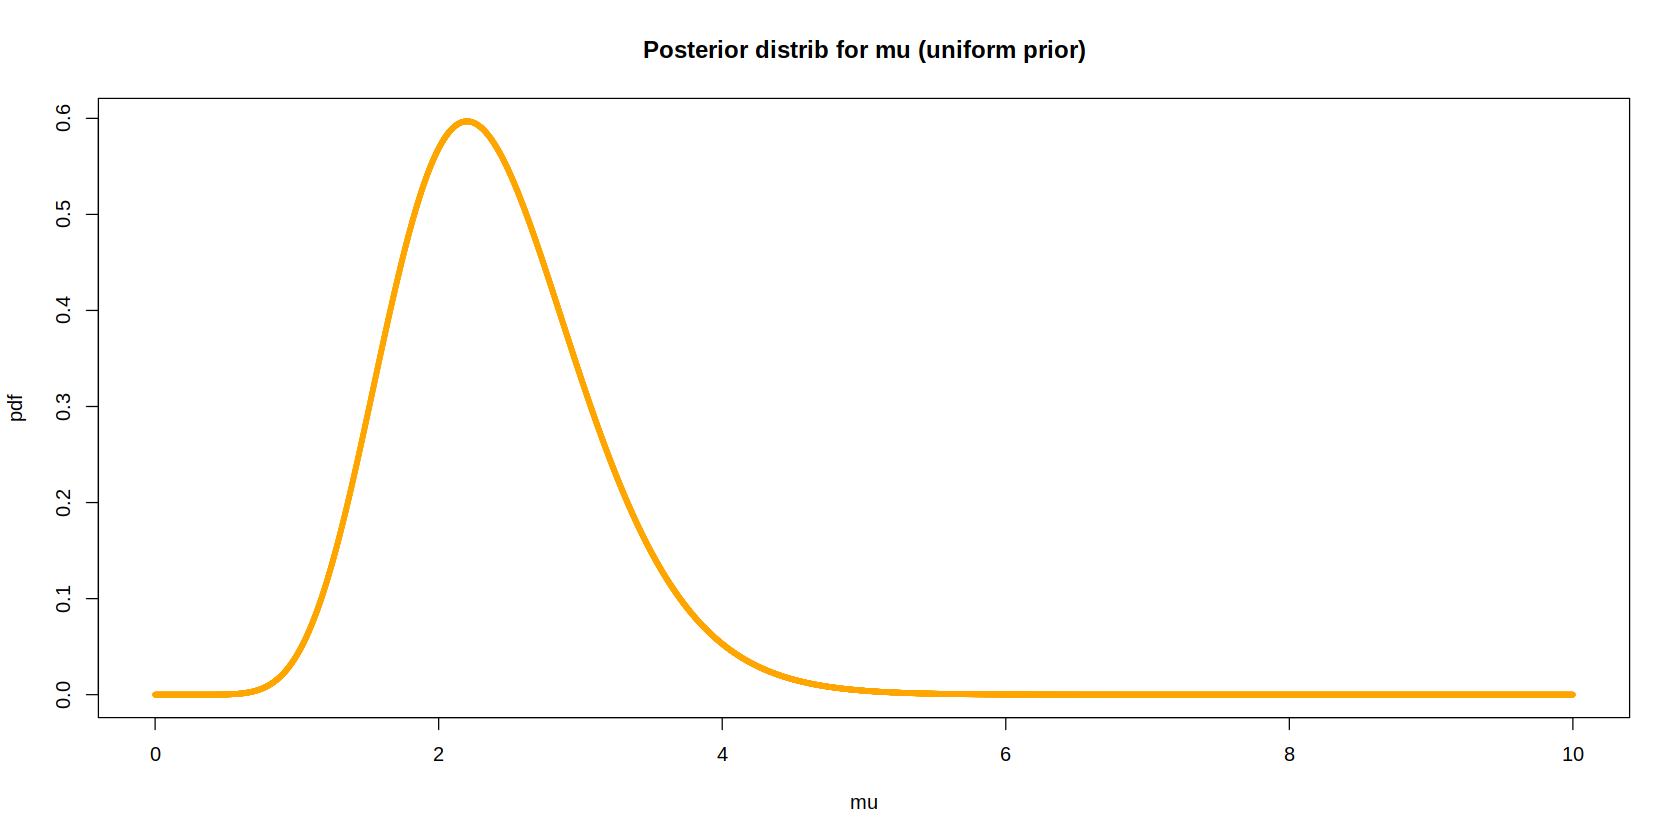

In [1]:
# DATA:
x <- c(3,0,1,5,2)
n <- length(x)

# PARAMETERS:
alpha1 <- sum(x) + 1
lambda1 <- 0 + n

# POSTERIOR:
x_ax <- seq( 0, 10, 0.001 )
mu_post = dgamma(x_ax, alpha1, lambda1)
mu_prior = dgamma(x_ax, 1, 0)

# PLOT:
options(repr.plot.width = 14, repr.plot.height = 7)
plot(x=x_ax, y=mu_post, type='p',col='orange',
    xlab = "mu",
    cex = 0.5, 
    ylab = "pdf",
    main = "Posterior distrib for mu (uniform prior)" )

In [2]:
# analytical solution for mean, median and variance
mean <- alpha1 / lambda1
median <- qgamma(0.5, alpha1, lambda1)
var <- alpha1 / lambda1^2
cat("ANALYTICAL SOLUTION:\nMean   ", mean, "\nMedian ", median, "\nVar    ", var)

# numerical solution for mean, median and variance
distrib <- rgamma(10000, alpha1, lambda1)
mean <- mean(distrib)
median <- median(distrib)
var <- var(distrib)
cat("\n\nNUMERICAL SOLUTION:\nMean   ", mean, "\nMedian ", median, "\nVar    ", var)

ANALYTICAL SOLUTION:
Mean    2.4 
Median  2.333673 
Var     0.48

NUMERICAL SOLUTION:
Mean    2.400738 
Median  2.33327 
Var     0.4710595

#### 2. Taking into account that historical data from similar factories suggest that the rate of defective washing machines is around 2 per day, with standard deviation of 1, model your belief using the suitable Gamma prior and then:
- Determine and draw the posterior distribution for μ, given the data
- Evaluate mean, median and variance, both analytically and numerically in R.

Similar to before, but now the uniform prior can be model as a Gamma distribution with mean and variance
$m=2$ and $s^2=1$, which mean a gamma distrib with parameters $\alpha= \left(  \frac{m}{s} \right)^2 = 4$ and $\lambda = \frac{m}{s^2}=2$.  
The posterior is given by a $Gamma(\alpha', \lambda')$ with $\alpha'= \sum y_j + \alpha$ and $\lambda' = \lambda + n$ (number of data).

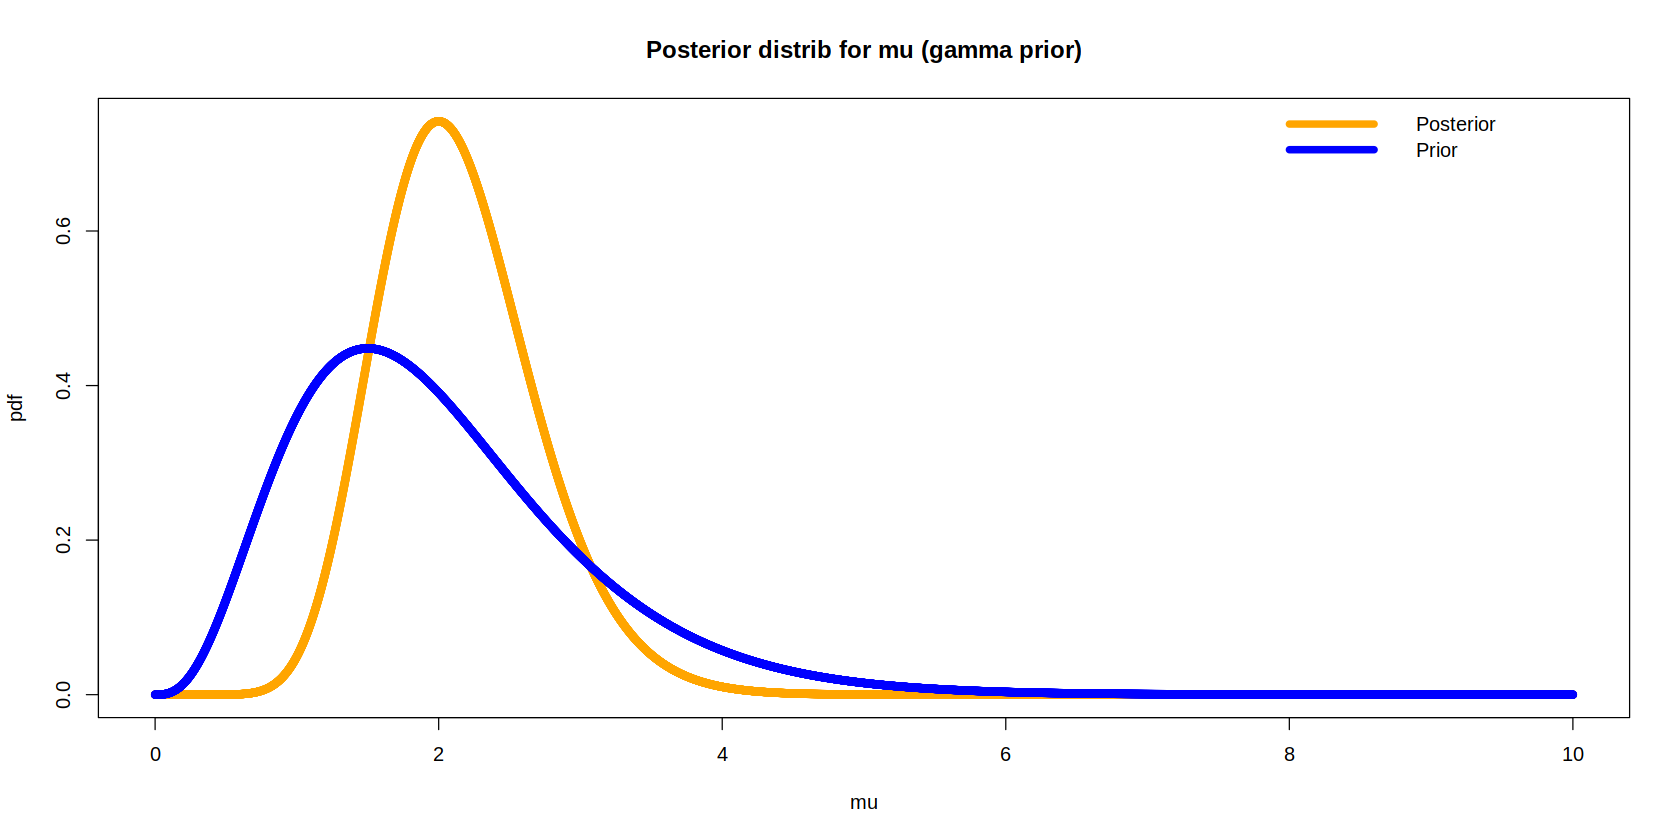

In [3]:
# PARAMETERS:
alpha2 <- sum(x) + 4
lambda2 <- 2 + n

# POSTERIOR:
x_ax <- seq( 0, 10, 0.001 )
mu_post = dgamma(x_ax, alpha2, lambda2)
mu_prior = dgamma(x_ax, 4, 2)

# PLOT:
options(repr.plot.width = 14, repr.plot.height = 7)
plot(x=x_ax, y=mu_post, type='p',col='orange',
    xlab = "mu",
    cex = 0.8, 
    ylab = "pdf",
    main = "Posterior distrib for mu (gamma prior)" )

points(x = x_ax, y = mu_prior, col = 'blue', cex = 0.8)

legend("topright", legend = c("Posterior", "Prior"),
       col = c("orange", "blue"), lwd = 6, bty = "n")

#### 3. Evaluate a 95% credibility interval for the results obtained with different priors (you can also try with other priors). In addition, compare the results obtained using Gamma posterior distribution with a normal approximation that matches the same mean and standard deviation.

In [10]:
# 95% credible interval from the Gamma posterior
interval1 <- qgamma(c(0.025, 0.975), shape = alpha1, rate = lambda1); interval1
interval2 <- qgamma(c(0.025, 0.975), shape = alpha2, rate = lambda2); interval2

# GAUSSIAN:
mean_mu1 <- alpha1 / lambda1
sd_mu1 <- sqrt(alpha1) / lambda1
interval_gaus1 <- qnorm(c(0.025, 0.975), mean = mean_mu1, sd = sd_mu1); interval_gaus1

mean_mu2 <- alpha2 / lambda2
sd_mu2 <- sqrt(alpha2) / lambda2
interval_gaus2 <- qnorm(c(0.025, 0.975), mean = mean_mu2, sd = sd_mu2); interval_gaus2

[1] 1.240115 3.936408

[1] 1.199341 3.355660

[1] 1.042097 3.757903

[1] 1.058442 3.227273

They are pretty similar

---

# Exercise 2: Efficiency using Bayesian approach
A researcher A wants to evaluate the efficiency of detector 2 (Det2). For this purpose,
he sets up the apparatus shown in the figure 1, where Det2 is sandwiched between Det1
and Det3. Let n be the number of signals recorded simultaneously by Det1 and Det3, and
r be those also recorded by Det2, researcher A obtains n = 20 and r = 12.

Assuming a binomial model where n is the number of trials and r is the number of success out of n trials:

#### 1. valuate the mean and the standard deviation using a Bayesian approach under the hypothesis of:
* – uniform prior ∼ U(0, 1)
* – Jeffrey’s prior ∼ Beta(1/2, 1/2)

A uniform prior corresponds to a special case of the Beta distribution, specifically $ \text{Beta}(1, 1) $.

Given this prior, the posterior distribution for the probability of success $p$ is a conjugate Beta distribution with parameters:

$$
\alpha' = r + \alpha = 13, \quad \beta' = n - r + \beta = 9
$$

So under the assumption of a uniform prior, the posterior mean and standard deviation for $p$ are:

$$
\text{MEAN} = \frac{\alpha}{\alpha + \beta} = \frac{13}{13 + 9} = \frac{13}{22} \approx 0.591
$$

$$
\text{STD} = \sqrt{ \frac{ \alpha \beta }{ (\alpha + \beta)^2 (\alpha + \beta + 1) } } 
= \sqrt{ \frac{13 \times 9}{22^2 \times 23} } \approx 0.103
$$

In [2]:
# PARAMETERS:
r <- 12
n <- 20
alpha_u <- r + 1   # 13
beta_u <- n-r+1    # 9
mean_u <- 13/22; mean_u
std_u <- sqrt(13*9/22/22/23); std_u

[1] 0.5909091

[1] 0.1025195

Jeffrey's prior corresponds to a special case of the Beta distribution, specifically $ \text{Beta}(1/2, 1/2) $.

Given this prior, the posterior distribution for the probability of success $p$ is a conjugate Beta distribution with parameters:

$$
\alpha' = r + \alpha = 25/2, \quad \beta' = n - r + \beta = 17/2
$$

So under the assumption of a uniform prior, the posterior mean and standard deviation for $p$ are:

$$
\text{MEAN} = \frac{\alpha}{\alpha + \beta}  \approx 0.595
$$

$$
\text{STD} = \sqrt{ \frac{ \alpha \beta }{ (\alpha + \beta)^2 (\alpha + \beta + 1) } } \approx 0.105
$$

In [5]:
# PARAMETERS:
r <- 12
n <- 20
alpha_j <- r + 1/2   # 25/2
beta_j <- n-r+1/2    # 17/2
mean_j <- alpha_j/ (alpha_j+beta_j); mean_j
std_j <- sqrt(alpha_j*beta_j/( (alpha_j+beta_j)^2 * (alpha_j+beta_j+1) )); std_j

[1] 0.5952381

[1] 0.1046487

#### 2. Plot the posterior distributions for both cases

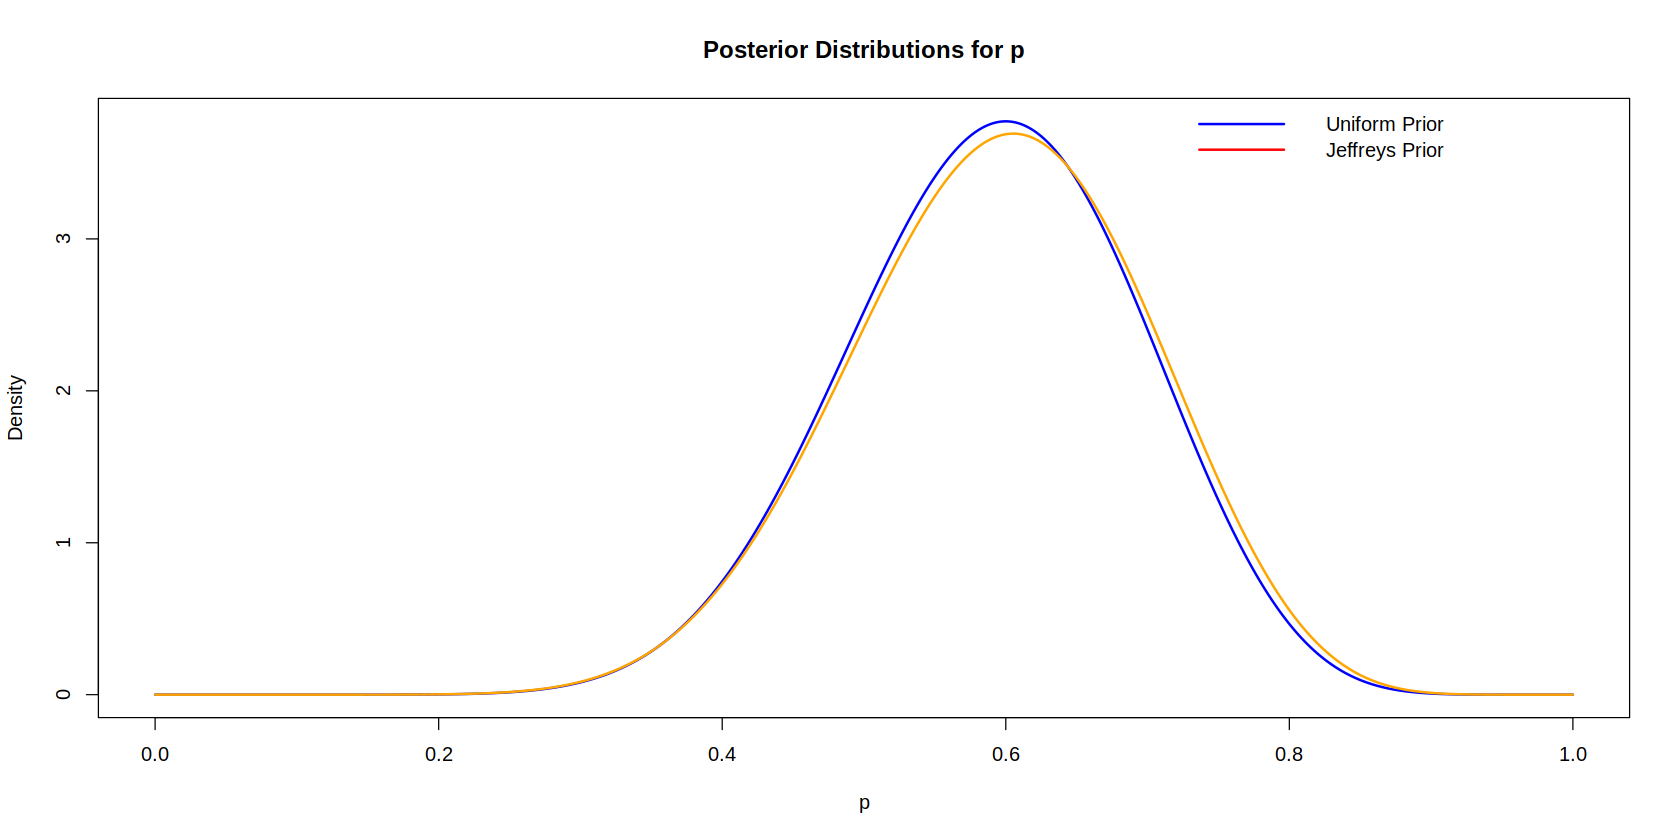

In [9]:
options(repr.plot.width = 14, repr.plot.height = 7)

# x-axis (possible values of p)
p <- seq(0, 1, length.out = 1000)

# Posterior densities
posterior_u <- dbeta(p, alpha_u, beta_u)
posterior_j <- dbeta(p, alpha_j, beta_j)

# Plot
plot(p, posterior_u, type = "l", lwd = 2, col = "blue",
     ylim = range(c(posterior_u, posterior_j)),
     xlab = "p", ylab = "Density", main = "Posterior Distributions for p")
lines(p, posterior_j, col = "orange", lwd = 2)

# Add legend
legend("topright", legend = c("Uniform Prior", "Jeffreys Prior"),
       col = c("blue", "red"), lwd = 2, bty = "n")

#### Taking into account that the same detector has been studied by researcher B, who has performed only n = 10 measurements and has obtained r = 10 signals:

#### 3. Evaluate the mean, the standard deviation and the posterior distribution using a uniform prior with the results of researcher B.

Using same calculation as before, we obtain $Beta(11,1)$.

In [15]:
# PARAMETERS:
r_b <- 10
n_b <- 10
alpha_b <- r_b + 1  
beta_b <- n_b-r_b+1  
mean_b <- alpha_b/ (alpha_b+beta_b); mean_b
std_b <- sqrt(alpha_b*beta_b/( (alpha_b+beta_b)^2 * (alpha_b+beta_b+1) )); std_b

[1] 0.9166667

[1] 0.07665552

#### 4. Repeat the computation of points a) and b) with the data of researcher A using as a prior the posterior obtained from point c).

In [21]:
# Updated posterior using A's data
alpha_new <- alpha_b + r   # 11 + 12 = 23
beta_new <- beta_b + n - r  # 1 + 8 = 9

mean_new <- alpha_new/ (alpha_new+beta_new); mean_new
std_new <- sqrt(alpha_new*beta_new/( (alpha_new+beta_new)^2 * (alpha_new+beta_new+1) )); std_new

[1] 0.71875

[1] 0.07826692

#### 5. Compute 95% credible interval using the posterior of the previous point d).

In [23]:
# 95% credible interval:
interval <- qbeta(c(0.025, 0.975), alpha_new, beta_new); interval

[1] 0.5538661 0.8577715

---

# Exercise 3 - Bayesian Inference for Binomial model
A coin is flipped n = 28 times with the following outcomes:  
`T, T, T, T, T, H, T, T, H, H, T, T, H, H, H, T, H, T, H, T, H, H, T, H, T, H, T, H `
(13 Heads, 15 Tails)

In [24]:
n <- 28 # total tries
r <- 13 # heads

#### 1. Assuming a flat prior, and a beta prior, plot the likelihood, prior and posterior distributions for the data set.

A flat (uniform) prior corresponds to a special case of the Beta distribution, specifically $ \text{Beta}(1, 1) $.

For the other we choose arbitrarily $ \text{Beta}(2, 2) $.

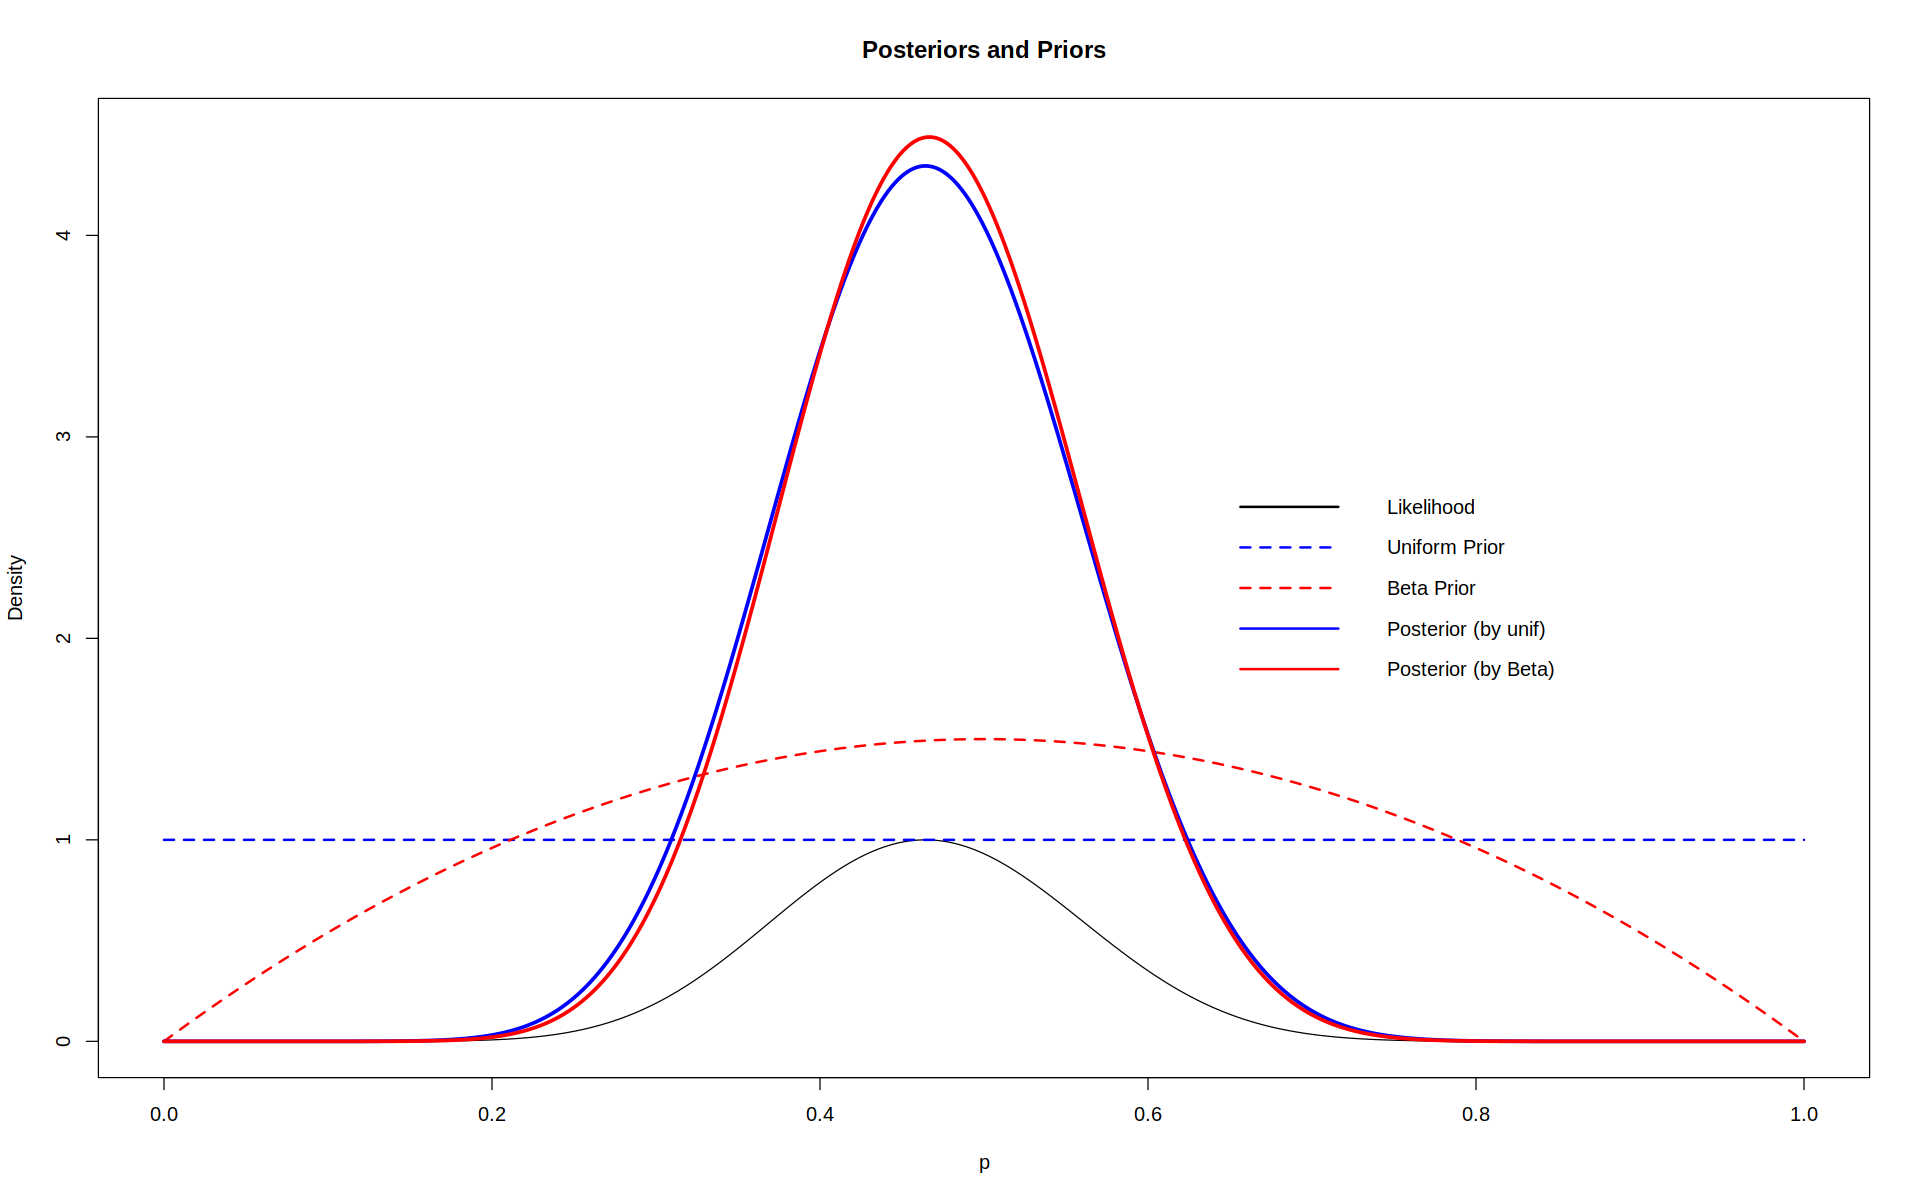

In [61]:
options(repr.plot.width = 16, repr.plot.height = 10)

# x-axis: range of p
p <- seq(0, 1, 0.0001)
likelihood <- factorial(n)/factorial(n-r)/factorial(r) * p^r * (1 - p)^(n - r)
likelihood <- likelihood / max(likelihood)  # normalized to max=1 for comparison

# Priors
prior_u <- dbeta(p, 1, 1)
prior_b <- dbeta(p, 2, 2)
# Posteriors
post_u <- dbeta(p, 14, 16)
post_b <- dbeta(p, 15, 17)

# Plot all
plot(p, likelihood, type = "l", lwd = 1, col = "black",
     ylab = "Density", xlab = "p", ylim=c(0,4.5),
     main = "Posteriors and Priors")
lines(p, prior_u, col = "blue", lwd = 2, lty = 2)
lines(p, prior_b, col = "red", lwd = 2, lty = 2)
lines(p, post_u, col = "blue", lwd = 3)
lines(p, post_b, col = "red", lwd = 3)

legend("right", legend = c("Likelihood", "Uniform Prior", "Beta Prior", 
                              "Posterior (by unif)", "Posterior (by Beta)"),
       col = c("black", "blue", "red", "blue", "red"),
       lty = c(1, 2, 2, 1, 1), lwd = 2, bty = "n")


#### 2. Evaluate the most probable value for the coin probability p and, integrating the posterior probability distribution, give an estimate for a 95% credibility interval.

In [69]:
# Posterior parameters
alpha_u <- 14
beta_u <- 16
alpha_b <- 15
beta_b <- 17

# modes:
mode_u <- (alpha_u - 1) / (alpha_u + beta_u - 2)
mode_b <- (alpha_b - 1) / (alpha_b + beta_b - 2)

# 95% Credible intervals
interval_u <- qbeta(c(0.025, 0.975), alpha_u, beta_u)
interval_b <- qbeta(c(0.025, 0.975), alpha_b, beta_b)

# Print results
cat("Posterior with unif prior:\n")
cat("    Mode:    ", round(mode_u, 3), "\n")
cat("    Interval:", round(interval_u[1], 3), "-", round(interval_u[2], 3), "\n\n")
cat("Posterior with Beta prior:\n")
cat("    Mode:    ", round(mode_b, 3), "\n")
cat("    Interval:", round(interval_b[1], 3), "-", round(interval_b[2], 3), "\n")


Posterior with unif prior:
    Mode:     0.464 
    Interval: 0.294 - 0.643 

Posterior with Beta prior:
    Mode:     0.467 
    Interval: 0.302 - 0.64 


#### 3. Repeat the same analysis assuming a sequential analysis of the data. Show how the most probable value and the credibility interval change as a function of the number of coin tosses (i.e. from 1 to 28).

Performing a sequential bayesian analysis means updating the posterior after each try.

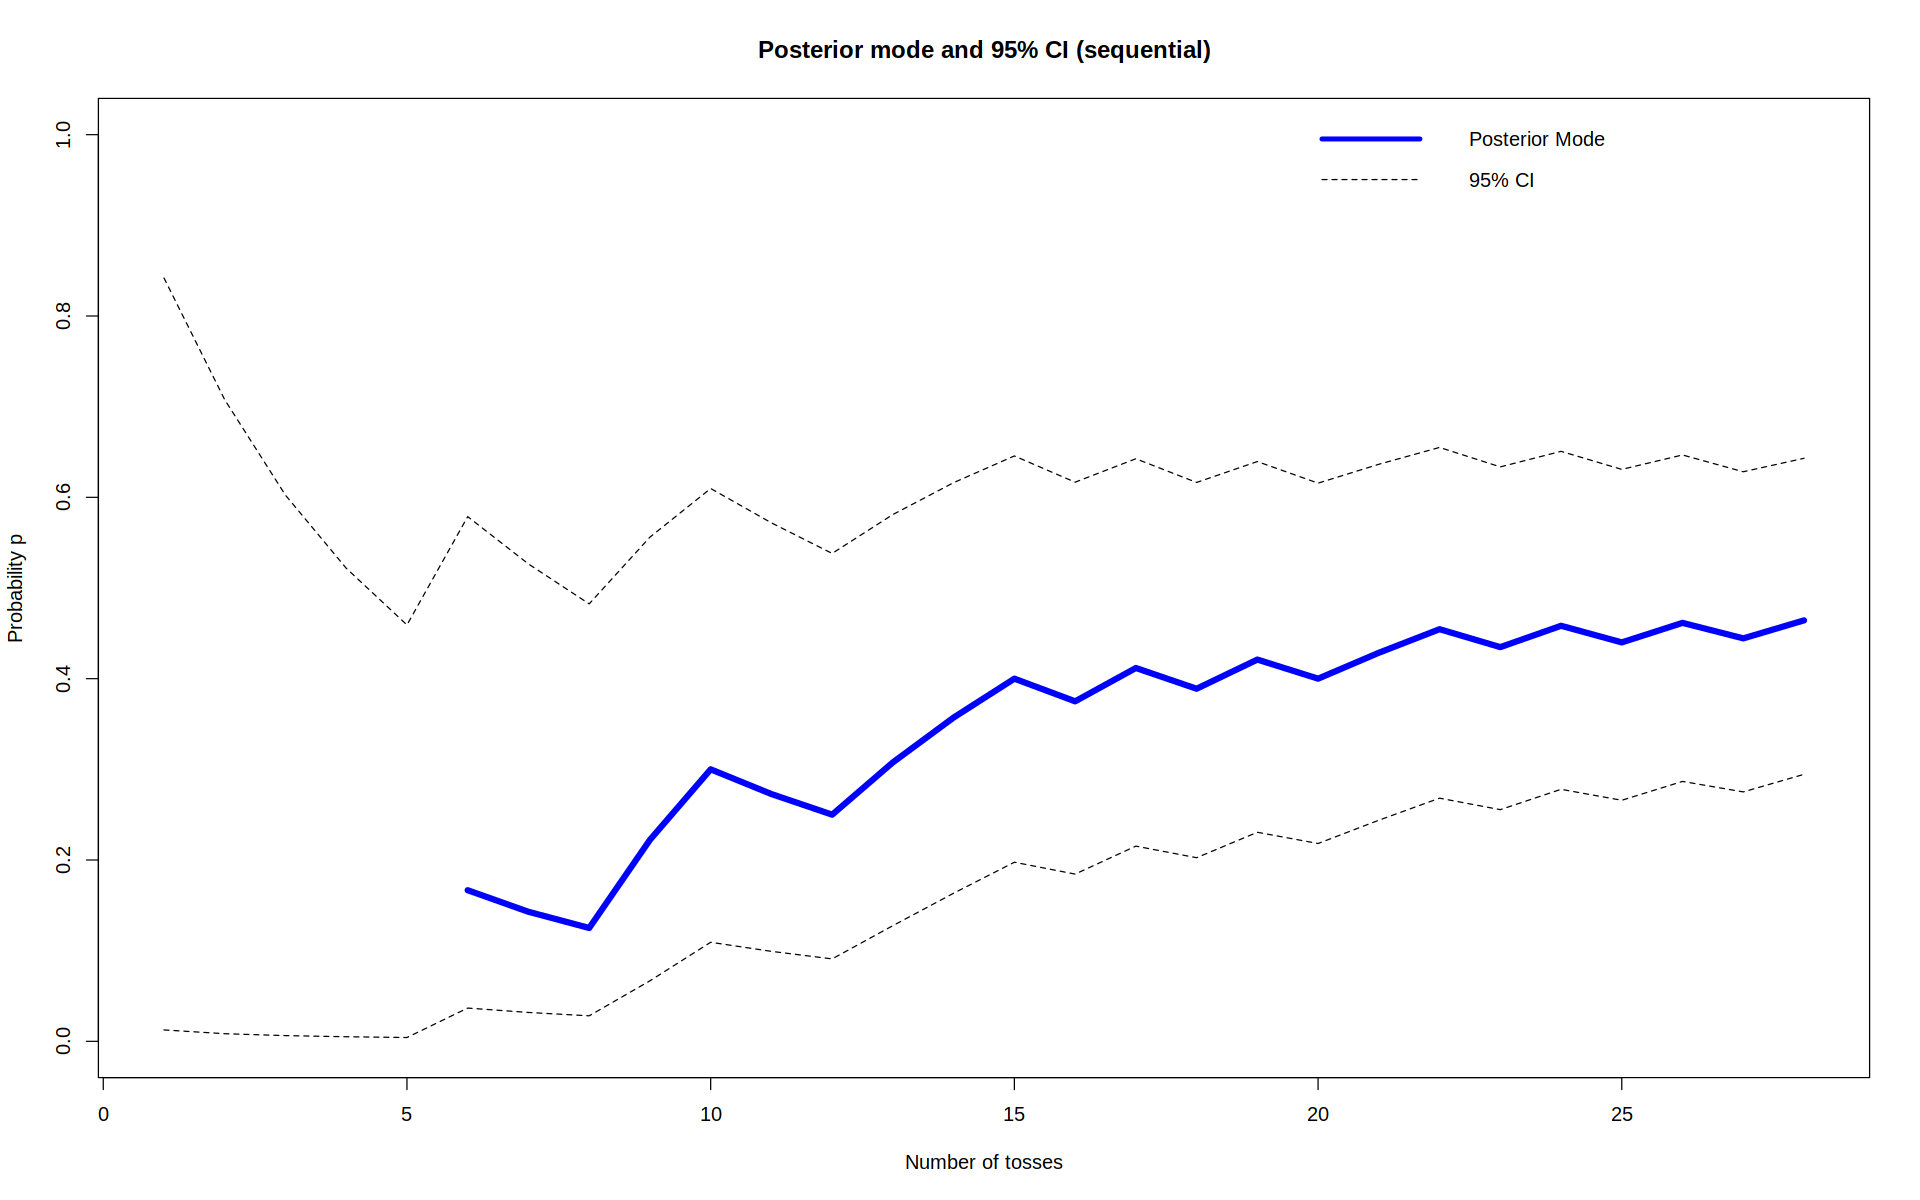

In [78]:
heads <- c(0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1,
            1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1)
cum_heads <- cumsum(heads)
n <- length(heads)

# Initialize results as zeros for now
mode <- numeric(n)
ci_low <- numeric(n)
ci_high <- numeric(n)

for (i in 1:n) {
  alpha <- cum_heads[i] + 1
  beta <- i - cum_heads[i] + 1
  
  # Mode (only defined when alpha > 1 and beta > 1)
  if (alpha > 1 && beta > 1) {
    mode[i] <- (alpha - 1) / (alpha + beta - 2)
  } else {
    mode[i] <- NA
  }
  
  # 95% credible interval
  ci <- qbeta(c(0.025, 0.975), alpha, beta)
  ci_low[i] <- ci[1]
  ci_high[i] <- ci[2]
}

# PLOT:
options(repr.plot.width = 16, repr.plot.height = 10)
plot(1:n, mode, type="l", col="blue", lwd=5,
     ylim=c(0, 1), xlab="Number of tosses", ylab="Probability p",
     main="Posterior mode and 95% CI (sequential)")
lines(1:n, ci_low, col="black", lty=2)
lines(1:n, ci_high, col="black", lty=2)
legend("topright", legend=c("Posterior Mode", "95% CI"),
       col=c("blue", "black"), lty=c(1, 2), lwd=c(4, 1), bty="n")


#### 4. Do you get a different result, by analysing the data sequentially with respect to a one-step analysis (i.e. considering all the data as a whole) ?